# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split

In [101]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [102]:
# Download the dataset
raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 4/data/tweet_sentiment_train.csv.zip')

In [103]:
raw_df.head()

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


Набір даних містить 4 колонки

In [104]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


У наборі є пропущені значення (по одному в 2-х колонках), тому для подальшої роботи рядки з пропущеними значеннями вилучимо

In [105]:
df = raw_df.dropna()

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27480 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27480 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27480 non-null  object
dtypes: object(4)
memory usage: 1.0+ MB


### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



,count
sentiment,
neutral,11117
positive,8582
negative,7781


,proportion
sentiment,
neutral,40.0
positive,31.0
negative,28.0


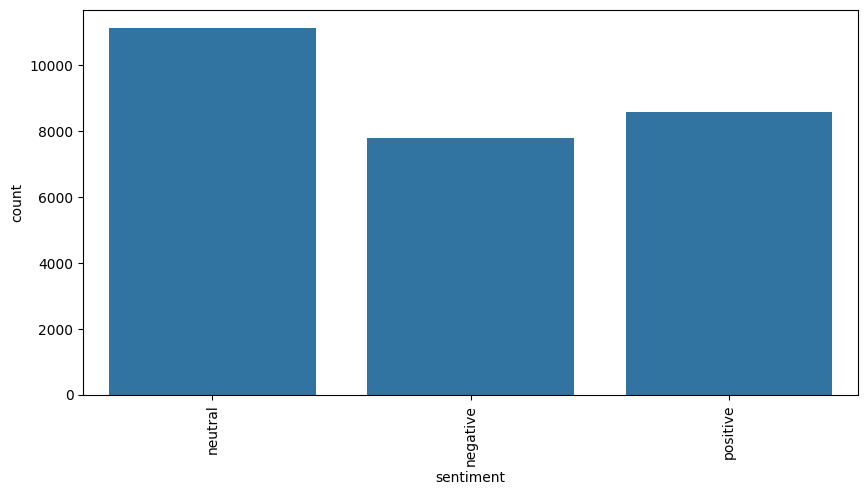

In [107]:
display(df['sentiment'].value_counts())
display(df['sentiment'].value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(data = df, x = 'sentiment')
plt.xticks(rotation = 90)
plt.show()

Розподіл міток ближчий до рівномірного, ніж незбалансованого з переважанням нейтральних відгуків. Найменше в наборі негативних міток.

,text
count,27480.000000
mean,68.330022
std,35.603870
min,3.000000
25%,39.000000
50%,64.000000
75%,97.000000
max,141.000000


,count
text,
41,308
48,301
46,301
42,298
45,295
...,...
4,8
3,5
139,4


,proportion
text,
41,1.0
48,1.0
46,1.0
42,1.0
45,1.0
...,...
4,0.0
3,0.0
139,0.0


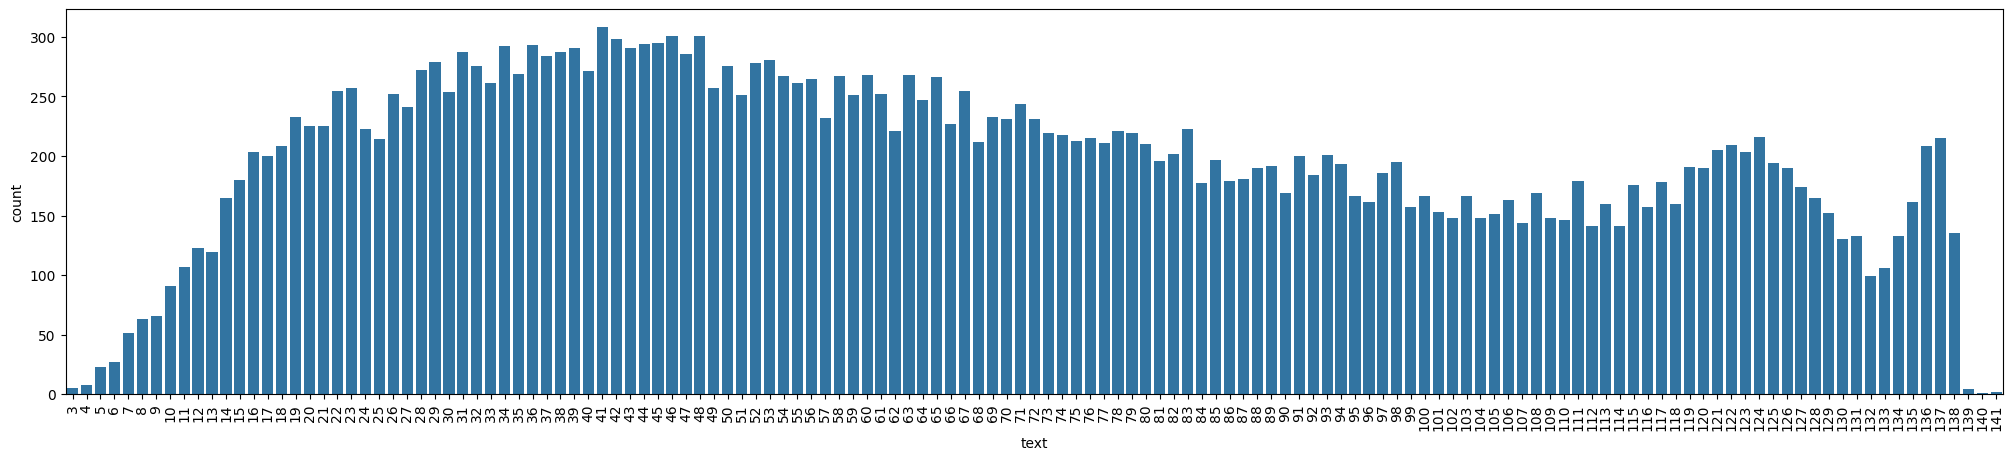

In [108]:
display(df['text'].str.len().describe())

display(df['text'].str.len().value_counts(ascending=False))
display(df['text'].str.len().value_counts(ascending=False, normalize=True).round(2)*100)

plt.figure(figsize = (25,5))
sns.countplot(data = df, x = df['text'].str.len())
plt.xticks(rotation = 90)
plt.show()

Розподіл довжин тексту в постах вказує на те, що в наборі даних переважають тексти довжиною 39-97 символів (1 та 3 квартилі), найбільше текстів довжиною 64 символи (медіана). Також розподіл вказує на те, що набір містить порівняно велику кількість записів довжиною близько 120 та 137 символів.

In [109]:
df[df['sentiment'] == 'negative']

,textID,text,selected_text,sentiment
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative
12,74a76f6e0a,My Sharpie is running DANGERously low on ink,DANGERously,negative
...,...,...,...,...
27464,e7eecffdc8,rec game....trying not to cry...the pain is to...,breakingg,negative
27470,778184dff1,lol i know and haha..did you fall asleep?? o...,t bored,negative
27472,8f5adc47ec,http://twitpic.com/663vr - Wanted to visit the...,were too late,negative
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative


,text
count,7781.000000
mean,70.488112
std,35.155991
min,5.000000
25%,42.000000
50%,66.000000
75%,98.000000
max,141.000000


,count
text,
48,96
41,91
43,90
52,88
55,87
...,...
6,3
5,2
139,2


,proportion
text,
48,1.0
41,1.0
43,1.0
52,1.0
55,1.0
...,...
6,0.0
5,0.0
139,0.0


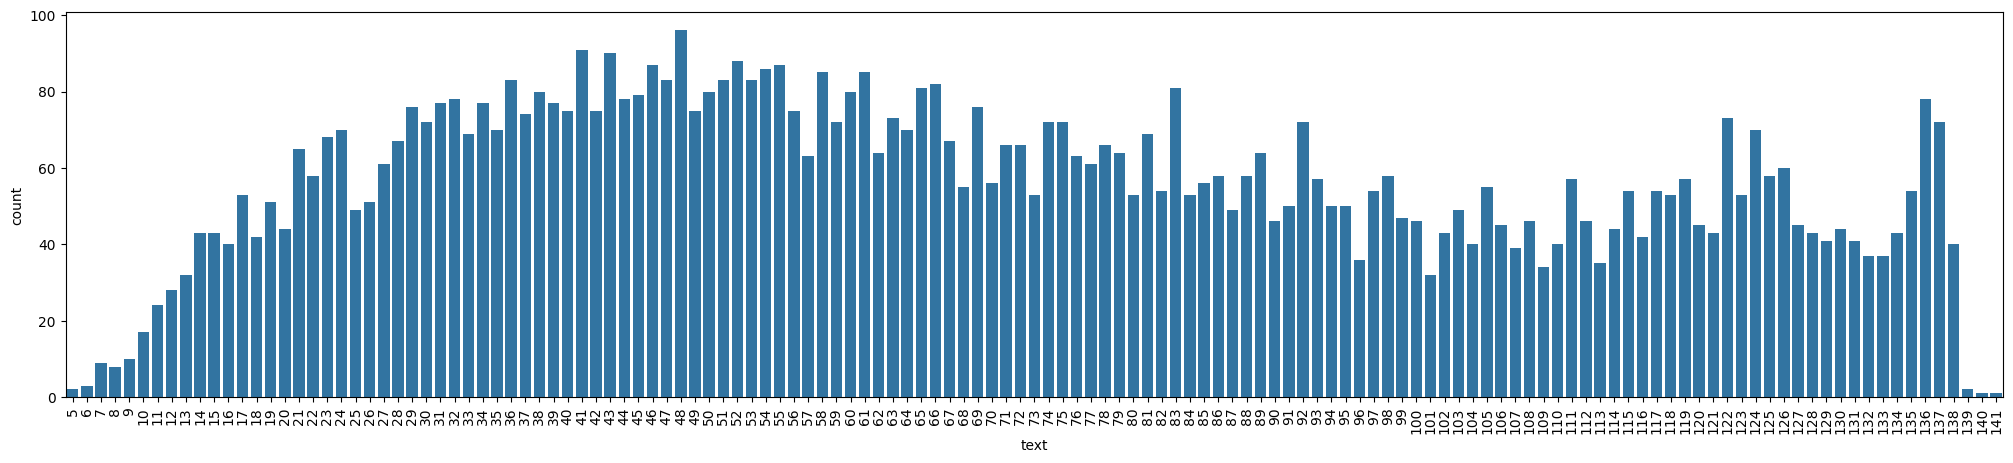

In [110]:
negative = df[df['sentiment'] == 'negative']

display(negative['text'].str.len().describe())

display(negative['text'].str.len().value_counts(ascending=False))
display(negative['text'].str.len().value_counts(ascending=False, normalize=True).round(2)*100)

plt.figure(figsize = (25,5))
sns.countplot(data = negative, x = negative['text'].str.len())
plt.xticks(rotation = 90)
plt.show()

,text
count,11117.00000
mean,65.20680
std,36.40755
min,3.00000
25%,35.00000
50%,59.00000
75%,94.00000
max,141.00000


,count
text,
28,137
22,133
23,129
19,127
41,127
...,...
5,17
4,8
3,5


,proportion
text,
28,1.0
22,1.0
23,1.0
19,1.0
41,1.0
...,...
5,0.0
4,0.0
3,0.0


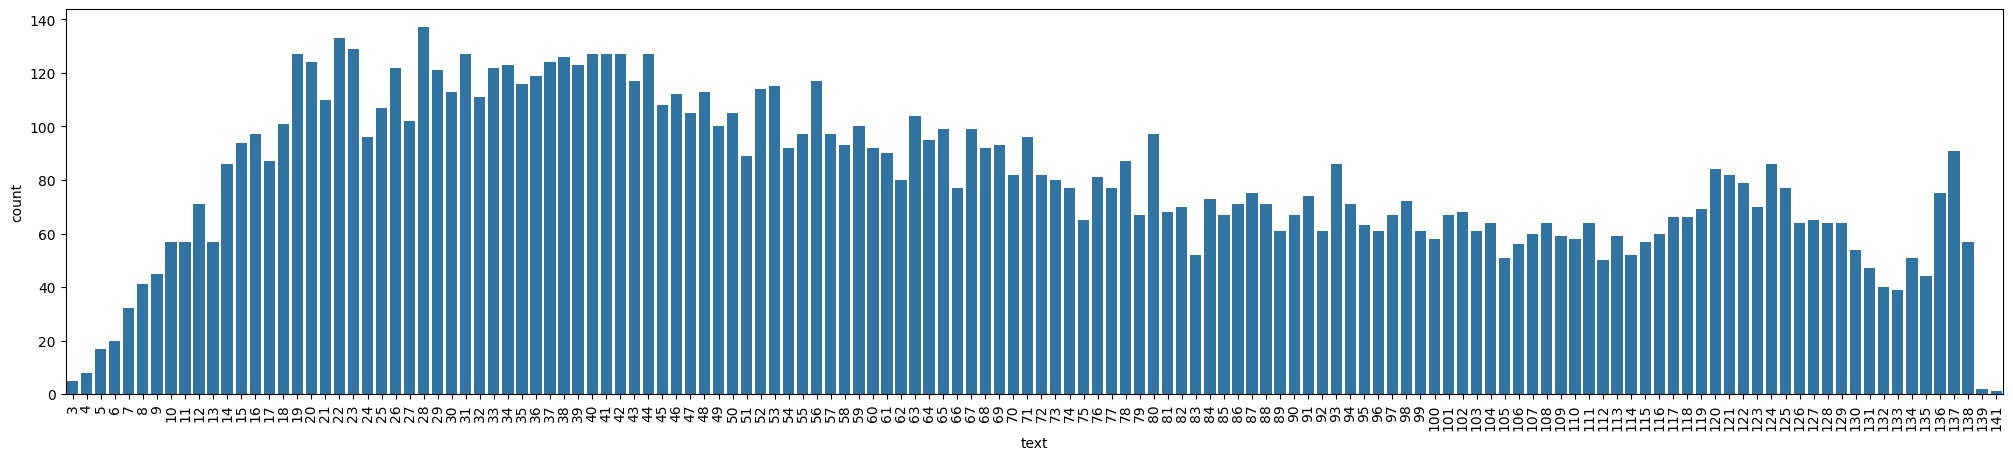

In [111]:
neutral = df[df['sentiment'] == 'neutral']

display(neutral['text'].str.len().describe())
display(neutral['text'].str.len().value_counts(ascending=False))
display(neutral['text'].str.len().value_counts(ascending=False, normalize=True).round(2)*100)

plt.figure(figsize = (25,5))
sns.countplot(data = neutral, x = neutral['text'].str.len())
plt.xticks(rotation = 90)
plt.show()

,text
count,8582.000000
mean,70.419133
std,34.647770
min,5.000000
25%,42.000000
50%,67.000000
75%,98.000000
max,138.000000


,count
text,
45,108
46,102
47,98
60,96
42,96
...,...
8,14
9,11
7,10


,proportion
text,
45,1.0
46,1.0
47,1.0
60,1.0
42,1.0
...,...
8,0.0
9,0.0
7,0.0


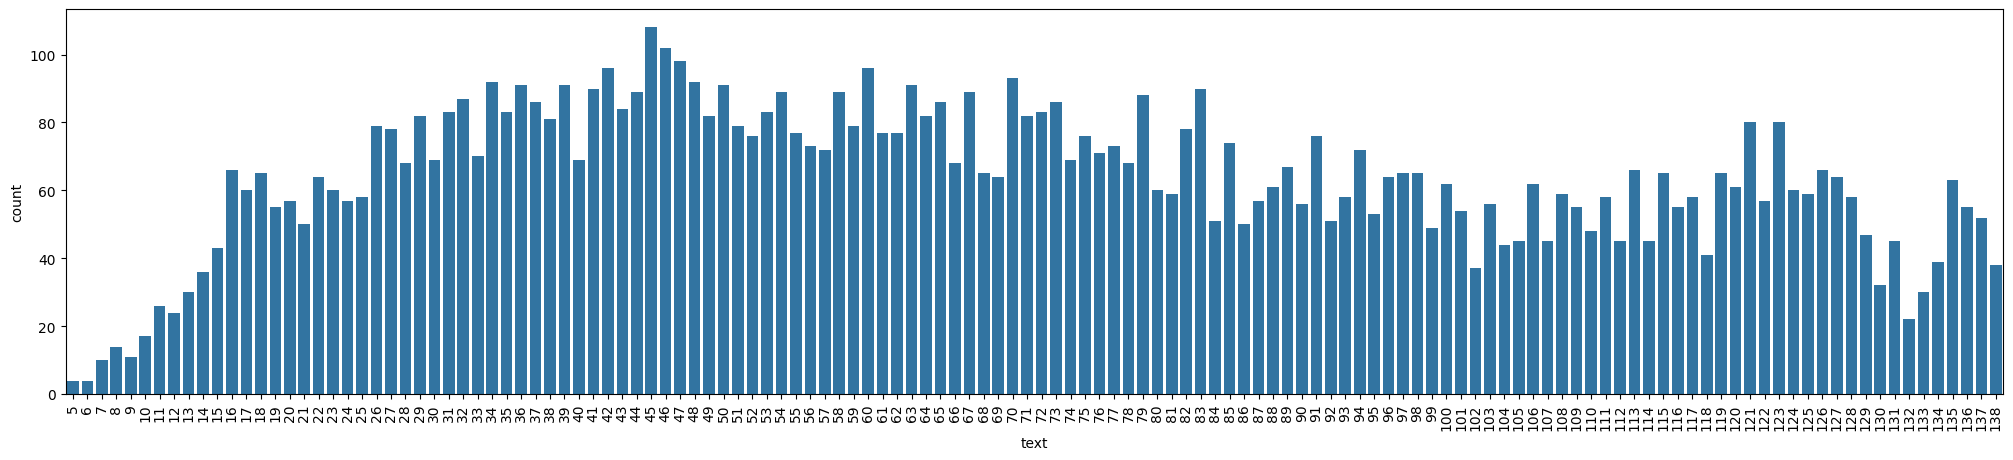

In [112]:
positive = df[df['sentiment'] == 'positive']

display(positive['text'].str.len().describe())
display(positive['text'].str.len().value_counts(ascending=False))
display(positive['text'].str.len().value_counts(ascending=False, normalize=True).round(2)*100)

plt.figure(figsize = (25,5))
sns.countplot(data = positive, x = positive['text'].str.len())
plt.xticks(rotation = 90)
plt.show()

На перший погляд, розподіл довжини тексту за мітками подібний, чітких аномалій не містить.

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




Порядок дій:
0. Датасет ділимо на тренувальний та тестовий. На тренувальному CountVectorizer буде виконано fit_transform, на тестовому - transform.
1. Задаємо змінну зі стоп-словами
2. Створюємо стеммінг змінну для англійської мови
3. Створюємо функцію токенізації, яка для кожного рядка тексту (рядка з таблиці) спочатку буде здійснювати токенізацію, і для кожного токенізованого слова одразу буде здійснювати стеммінг)
4. У CountVectorizer передамо функцію для токенізації, а стоп-слова передамо в параметр stopwords. Також явно задамо параметр за замовчуванням lowercase=True

Завантаження стоп-слів

In [113]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [114]:
english_stopwords = stopwords.words('english')

Стемінг

In [115]:
stemmer = SnowballStemmer(language='english')

Токенізація

In [116]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [117]:
def tokenize(text):
  return [stemmer.stem(word) for word in word_tokenize(text)]

Векторизація

In [118]:
vectorizer = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=2000
)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



#### Розділення та обробка тренувального та тестового наборів

In [119]:
X_train, X_test, y_train, y_test = train_test_split(df["text"].astype(str), df["sentiment"], test_size=0.2, random_state=42)

In [120]:
X_train_bow = vectorizer.fit_transform(X_train)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


In [121]:
X_test_bow = vectorizer.transform(X_test)

Подивимось, які слова збереглися в словнику після токенізації

In [122]:
feature_names = vectorizer.get_feature_names_out()
print(list(feature_names)[:100])

['!', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '--', '-p', '.', '..', '...', '....', '.....', '......', '.......', '........', '/', '//tweet.sg', '0', '1', '1/2', '10', '100', '11', '12', '13', '14', '140', '15', '16', '17', '18', '1st', '2', '2.', '20', '200', '21', '24', '25', '2day', '2moro', '2nd', '2nite', '3', '30', '33', '3d', '3rd', '4', '40', '45', '4th', '5', '50', '6', '6th', '7', '8', '80', '9', '90', '9am', ':', ';', '<', '=', '=d', '>', '?', '@', '[', ']', '^^', '_', '`', 'abl', 'absolut', 'abt', 'accept', 'access', 'accid', 'accident', 'account', 'ace', 'ach', 'across', 'act', 'action', 'activ', 'actual', 'ad', 'adam', 'add']


Бачимо, що окрім слів та чисел до словника потрапили також символи. Потрібно підкоригувати функцію tokenize

In [123]:
import re

def tokenize(text):
  # Change all words to lowercase
  text = str(text).lower()
  # Keeps ONLY lowercase letters and spaces, remove numbers
  text = re.sub(r'[^a-z\s]', '', text)
  # Tokenize only words
  words = word_tokenize(text)

  return [stemmer.stem(word) for word in words]

In [124]:
vectorizer_words = CountVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=2000
)

In [125]:
X_train_bow = vectorizer_words.fit_transform(X_train)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'ani', 'arent', 'becaus', 'befor', 'couldnt', 'didnt', 'doe', 'doesnt', 'dont', 'dure', 'hadnt', 'hasnt', 'havent', 'hed', 'hell', 'hes', 'id', 'ill', 'im', 'isnt', 'itd', 'itll', 'ive', 'mightnt', 'mustnt', 'neednt', 'onc', 'onli', 'ourselv', 'shant', 'shed', 'shell', 'shes', 'shouldnt', 'shouldv', 'thatll', 'themselv', 'theyd', 'theyll', 'theyr', 'theyv', 'veri', 'wasnt', 'wed', 'well', 'werent', 'weve', 'whi', 'wont', 'wouldnt', 'youd', 'youll', 'yourselv', 'youv'] not in stop_words.
  warnings.warn(


In [126]:
X_test_bow = vectorizer_words.transform(X_test)

In [127]:
feature_names = vectorizer_words.get_feature_names_out()
print(list(feature_names)[:100])

['abl', 'absolut', 'abt', 'ac', 'accept', 'access', 'accid', 'accident', 'accord', 'account', 'ace', 'ach', 'across', 'act', 'action', 'activ', 'actual', 'ad', 'adam', 'add', 'addict', 'address', 'admit', 'adopt', 'ador', 'advanc', 'advic', 'afford', 'afraid', 'afternoon', 'age', 'ago', 'agre', 'ah', 'aha', 'ahaha', 'ahead', 'ahh', 'ahhh', 'ahhhh', 'aim', 'aint', 'air', 'airport', 'aka', 'al', 'ala', 'alarm', 'album', 'alcohol', 'alex', 'aliv', 'allergi', 'allow', 'almost', 'alon', 'along', 'alot', 'alreadi', 'alright', 'also', 'although', 'alway', 'amaz', 'america', 'american', 'ang', 'angel', 'angri', 'ani', 'anim', 'ankl', 'anna', 'anniversari', 'announc', 'annoy', 'anoth', 'answer', 'anybodi', 'anymor', 'anyon', 'anyth', 'anytim', 'anyway', 'anywher', 'apart', 'apolog', 'app', 'appar', 'appear', 'appl', 'appli', 'appoint', 'appreci', 'appt', 'area', 'arent', 'argh', 'arm', 'around']


Тепер словник містить лише токенізовані слова

In [128]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, f1_score

#### Навчання класифікаторів

##### LogisticRegression


In [129]:
model_logreg = LogisticRegression(max_iter=1000)

In [130]:
model_logreg.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

In [131]:
train_preds = model_logreg.predict(X_train_bow)
test_preds = model_logreg.predict(X_test_bow)

Порівняємо розподіл передбачених та цільових міток та оцінимо якість класифікатора

Train Pred Targets


,count
neutral,10085
positive,6518
negative,5381


,proportion
neutral,46.0
positive,30.0
negative,24.0


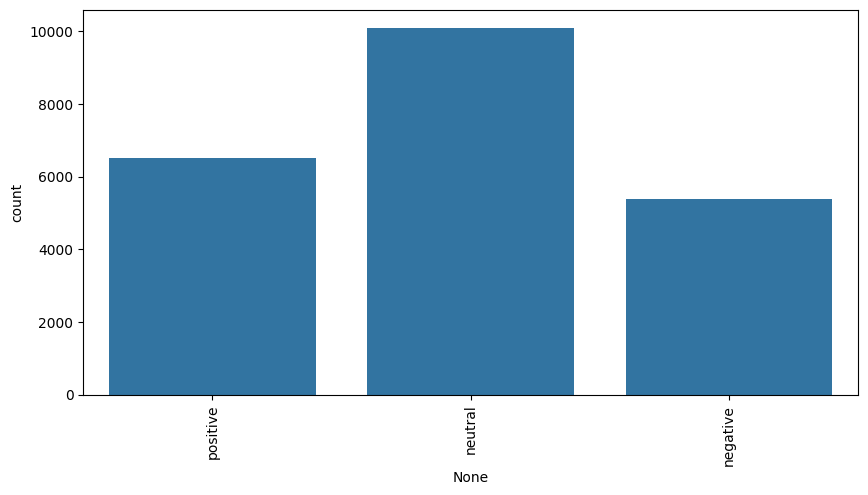

In [132]:
print('Train Pred Targets')
display(pd.Series(train_preds).value_counts())
display(pd.Series(train_preds).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(train_preds))
plt.xticks(rotation = 90)
plt.show()

Train Targets


,count
sentiment,
neutral,8881
positive,6894
negative,6209


,proportion
sentiment,
neutral,40.0
positive,31.0
negative,28.0


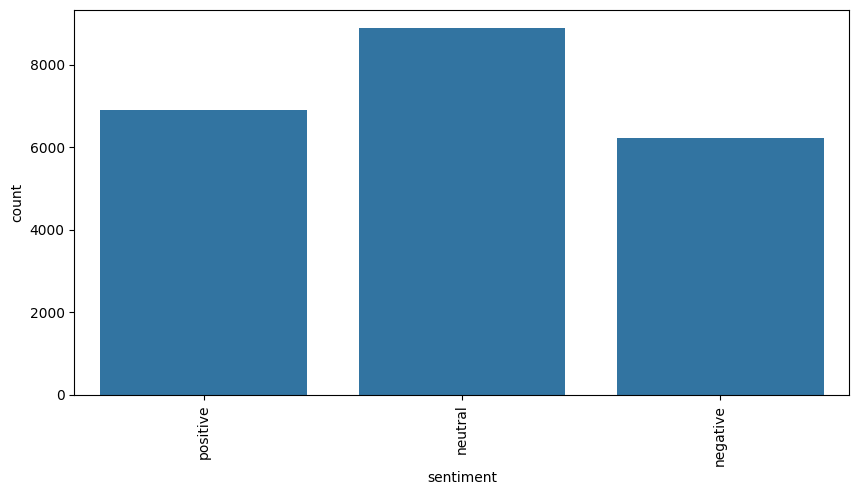

In [133]:
print('Train Targets')
display(pd.Series(y_train).value_counts())
display(pd.Series(y_train).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(y_train))
plt.xticks(rotation = 90)
plt.show()

In [134]:
from sklearn.metrics import classification_report

print("Train:")
display(f'Train F1: {f1_score(y_train, train_preds, average="weighted"):.2f}')
print(classification_report(y_train, train_preds))

print("Test:")
display(f'Test F1: {f1_score(y_test, test_preds, average="weighted"):.2f}')
print(classification_report(y_test, test_preds))

Train:


'Train F1: 0.77'

              precision    recall  f1-score   support

    negative       0.80      0.70      0.75      6209
     neutral       0.71      0.81      0.76      8881
    positive       0.82      0.78      0.80      6894

    accuracy                           0.77     21984
   macro avg       0.78      0.76      0.77     21984
weighted avg       0.77      0.77      0.77     21984

Test:


'Test F1: 0.69'

              precision    recall  f1-score   support

    negative       0.70      0.59      0.64      1572
     neutral       0.64      0.73      0.68      2236
    positive       0.76      0.72      0.74      1688

    accuracy                           0.69      5496
   macro avg       0.70      0.68      0.69      5496
weighted avg       0.69      0.69      0.69      5496



##### DecisionTree

In [135]:
model_tree = DecisionTreeClassifier(random_state=42, class_weight='balanced')

In [136]:
model_tree.fit(X_train_bow, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [137]:
train_preds_tree = model_tree.predict(X_train_bow)
test_preds_tree = model_tree.predict(X_test_bow)

Train Targets


,count
sentiment,
neutral,8881
positive,6894
negative,6209


,proportion
sentiment,
neutral,40.0
positive,31.0
negative,28.0


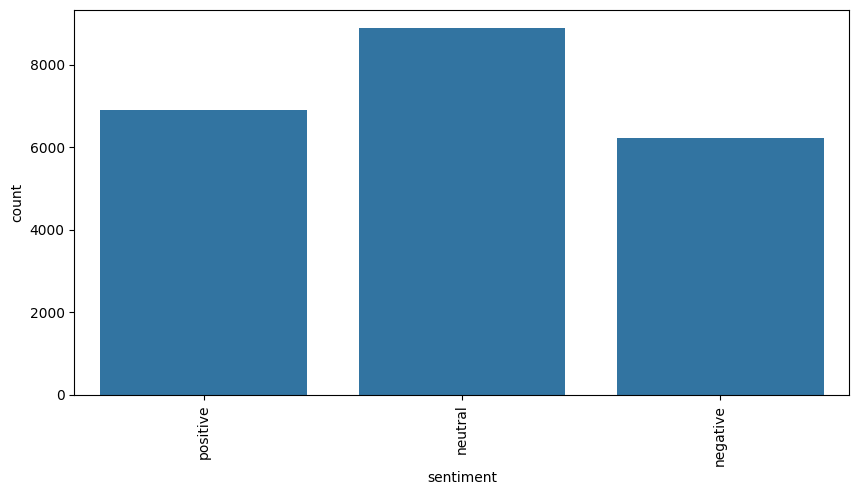

Train Pred Targets


,count
neutral,8897
positive,6888
negative,6199


,proportion
neutral,40.0
positive,31.0
negative,28.0


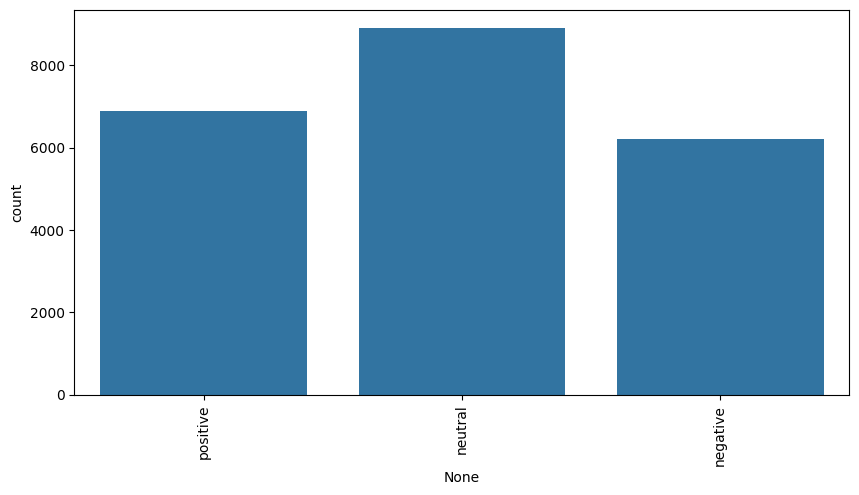

In [138]:
print('Train Targets')
display(pd.Series(y_train).value_counts())
display(pd.Series(y_train).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(y_train))
plt.xticks(rotation = 90)
plt.show()

print('Train Pred Targets')
display(pd.Series(train_preds_tree).value_counts())
display(pd.Series(train_preds_tree).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(train_preds_tree))
plt.xticks(rotation = 90)
plt.show()

In [139]:
print("Train:")
display(f'Train F1: {f1_score(y_train, train_preds_tree, average="weighted"):.2f}')
print(classification_report(y_train, train_preds_tree))

print("Test:")
display(f'Test F1: {f1_score(y_test, test_preds_tree, average="weighted"):.2f}')
print(classification_report(y_test, test_preds_tree))

Train:


'Train F1: 0.99'

              precision    recall  f1-score   support

    negative       0.99      0.99      0.99      6209
     neutral       0.99      0.99      0.99      8881
    positive       0.99      0.99      0.99      6894

    accuracy                           0.99     21984
   macro avg       0.99      0.99      0.99     21984
weighted avg       0.99      0.99      0.99     21984

Test:


'Test F1: 0.63'

              precision    recall  f1-score   support

    negative       0.59      0.62      0.61      1572
     neutral       0.64      0.57      0.60      2236
    positive       0.66      0.72      0.69      1688

    accuracy                           0.63      5496
   macro avg       0.63      0.64      0.63      5496
weighted avg       0.63      0.63      0.63      5496



In [140]:
def max_depth_and_leaf_nodes_error(md, mln, train_inputs, train_targets, test_inputs, test_targets):
    model_tree = DecisionTreeClassifier(max_depth=md, max_leaf_nodes=mln, random_state=42, class_weight='balanced')
    model_tree.fit(train_inputs, train_targets)

    train_preds = model_tree.predict(train_inputs)
    test_preds = model_tree.predict(test_inputs)

    train_f1 = f1_score(train_targets, train_preds, average="weighted")
    test_f1 = f1_score(test_targets, test_preds, average="weighted")

    return {'Max Depth': md, 'Max Leaf Nodes': mln, 'Training F1': train_f1, 'Test F1': test_f1}

In [141]:
model_tree.get_depth()

1061

In [142]:
model_tree.get_n_leaves()

np.int64(9366)

Бачимо, що натреноване дерево дуже глибоке та має значний оверфіт.

##### LightGBM

Оскільки набір даних дуже великий, для швидшої роботи та меншого використання пам'яті натренуємо алгоритм бустингу LightGBM. Подивимось на якість моделі із налаштуваннями за замовчуванням.

In [143]:
import lightgbm as lgb

In [144]:
model_lgb = lgb.LGBMClassifier()

In [146]:
X_train_float = X_train_bow.astype(np.float32)
X_test_float = X_test_bow.astype(np.float32)

In [148]:
model_lgb.fit(X_train_float, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.248135 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2917
[LightGBM] [Info] Number of data points in the train set: 21984, number of used features: 1089
[LightGBM] [Info] Start training from score -1.264315
[LightGBM] [Info] Start training from score -0.906401
[LightGBM] [Info] Start training from score -1.159663


LGBMClassifier()

In [150]:
train_preds_lgb = model_lgb.predict(X_train_float)
test_preds_lgb = model_lgb.predict(X_test_float)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train Targets


,count
sentiment,
neutral,8881
positive,6894
negative,6209


,proportion
sentiment,
neutral,40.0
positive,31.0
negative,28.0


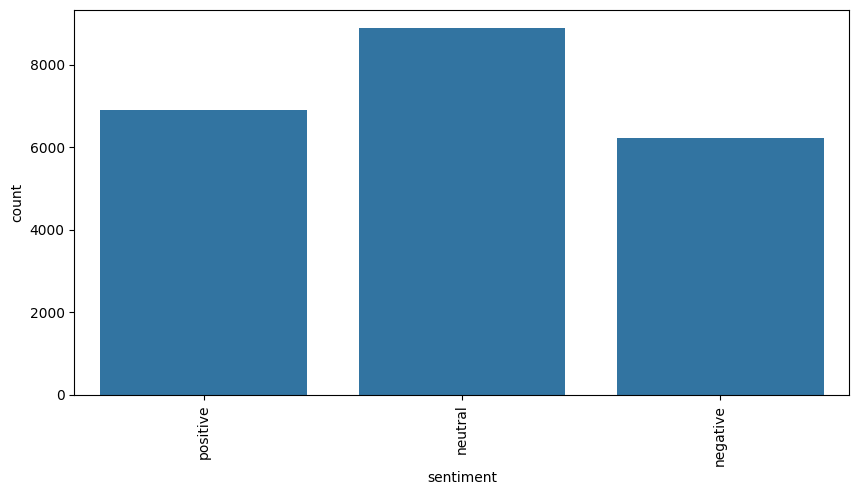

Train Pred Targets


,count
neutral,10525
positive,6596
negative,4863


,proportion
neutral,48.0
positive,30.0
negative,22.0


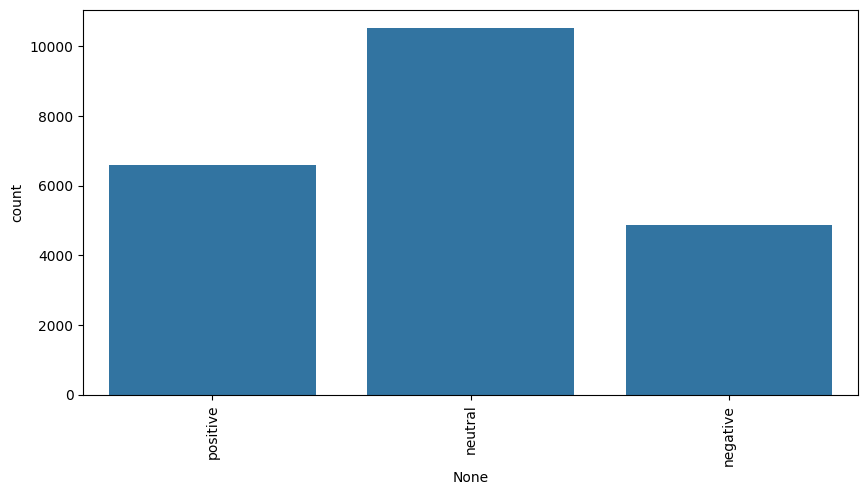

In [151]:
print('Train Targets')
display(pd.Series(y_train).value_counts())
display(pd.Series(y_train).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(y_train))
plt.xticks(rotation = 90)
plt.show()

print('Train Pred Targets')
display(pd.Series(train_preds_lgb).value_counts())
display(pd.Series(train_preds_lgb).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(train_preds_lgb))
plt.xticks(rotation = 90)
plt.show()

In [152]:
print("Train:")
display(f'Train F1: {f1_score(y_train, train_preds_lgb, average="weighted"):.2f}')
print(classification_report(y_train, train_preds_lgb))

print("Test:")
display(f'Test F1: {f1_score(y_test, test_preds_lgb, average="weighted"):.2f}')
print(classification_report(y_test, test_preds_lgb))

Train:


'Train F1: 0.74'

              precision    recall  f1-score   support

    negative       0.80      0.62      0.70      6209
     neutral       0.68      0.81      0.74      8881
    positive       0.80      0.77      0.78      6894

    accuracy                           0.74     21984
   macro avg       0.76      0.73      0.74     21984
weighted avg       0.75      0.74      0.74     21984

Test:


'Test F1: 0.70'

              precision    recall  f1-score   support

    negative       0.75      0.56      0.64      1572
     neutral       0.65      0.77      0.70      2236
    positive       0.76      0.76      0.76      1688

    accuracy                           0.70      5496
   macro avg       0.72      0.70      0.70      5496
weighted avg       0.71      0.70      0.70      5496



Отримали трохи кращий результат, ніж результат моделі логістичної регресії.

In [153]:
model_lgb_350 = lgb.LGBMClassifier(n_estimators = 350)

In [154]:
model_lgb_350.fit(X_train_float, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.161346 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2917
[LightGBM] [Info] Number of data points in the train set: 21984, number of used features: 1089
[LightGBM] [Info] Start training from score -1.264315
[LightGBM] [Info] Start training from score -0.906401
[LightGBM] [Info] Start training from score -1.159663


LGBMClassifier(n_estimators=350)

In [155]:
train_preds_lgb_350 = model_lgb_350.predict(X_train_float)
test_preds_lgb_350 = model_lgb_350.predict(X_test_float)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [156]:
print("Train:")
display(f'Train F1: {f1_score(y_train, train_preds_lgb_350, average="weighted"):.2f}')
print(classification_report(y_train, train_preds_lgb_350))

print("Test:")
display(f'Test F1: {f1_score(y_test, test_preds_lgb_350, average="weighted"):.2f}')
print(classification_report(y_test, test_preds_lgb_350))

Train:


'Train F1: 0.78'

              precision    recall  f1-score   support

    negative       0.83      0.69      0.76      6209
     neutral       0.73      0.84      0.78      8881
    positive       0.84      0.80      0.82      6894

    accuracy                           0.79     21984
   macro avg       0.80      0.78      0.78     21984
weighted avg       0.79      0.79      0.78     21984

Test:


'Test F1: 0.70'

              precision    recall  f1-score   support

    negative       0.72      0.59      0.64      1572
     neutral       0.65      0.74      0.69      2236
    positive       0.76      0.75      0.75      1688

    accuracy                           0.70      5496
   macro avg       0.71      0.69      0.70      5496
weighted avg       0.70      0.70      0.70      5496



Бачимо більшу розбіжність F1-Score на тренувальних та тестових даних, ніж при 100 естіматорах за замовчуванням, до того ж, на тестовій вибірці F1 не покращився. Тому обираємо модель LigthGBM із гіперпараметрами за замовчуванням як більш оптимальну серед натренованих вище моделей

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [157]:
feature_importance = pd.Series(model_lgb.feature_importances_, index=vectorizer_words.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance.head(20)

,imp
love,107
miss,101
thank,86
good,84
sad,80
hope,80
awesom,72
sorri,71
happi,71
great,68


Оскільки при попередній обробці даних було залишено лише слова та відкинуто знаки та числа, серед найбільш впливових ознак бачимо лише слова

Також видно, що найбільший вплив мають слова, які, швидше за все, утворюють позитивний клас

Використаємо LightGBM's Native SHAP для детальнішого пояснення результатів моделі

In [158]:
model_lgb.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [159]:
# Get the list of SHAP arrays (one array per class)
shap_contrib = model_lgb.predict(X_test_float, pred_contrib=True)

# Get the model's actual predictions for the test set
test_preds = model_lgb.predict(X_test_float)

# Define classes based on model_lgb.classes_ order
class_labels = ['negative', 'neutral', 'positive']

for class_idx, class_name in enumerate(class_labels):
    # Get SHAP values for this specific class
    class_shap = shap_contrib[class_idx][:, :-1]
    if hasattr(class_shap, "toarray"):
        class_shap = class_shap.toarray()

    # Select only rows where the model predicted this class
    predicted_as_class = (test_preds == class_name)

    if np.sum(predicted_as_class) > 0:
        # Calculate mean absolute SHAP only on rows belonging to this prediction
        mean_shap = np.abs(class_shap[predicted_as_class]).mean(axis=0)

        feat_imp = pd.Series(
            mean_shap,
            index=vectorizer_words.get_feature_names_out(),
            name=f'shap_{class_name}'
        ).sort_values(ascending=False)

        print(f"\n--- Top 10 Features defining '{class_name.upper()}' predictions ---")
        print(feat_imp.head(10))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Top 10 Features defining 'NEGATIVE' predictions ---
miss     0.212394
sad      0.158498
hate     0.101473
sorri    0.101078
love     0.088905
bad      0.069966
suck     0.068809
bore     0.067984
feel     0.063870
thank    0.060789
Name: shap_negative, dtype: float32

--- Top 10 Features defining 'NEUTRAL' predictions ---
good     0.029536
happi    0.028330
thank    0.027602
love     0.026928
like     0.019464
feel     0.018225
miss     0.017747
go       0.016703
back     0.016094
sad      0.015620
Name: shap_neutral, dtype: float32

--- Top 10 Features defining 'POSITIVE' predictions ---
love      0.272282
good      0.230771
thank     0.221606
happi     0.200474
great     0.112366
hope      0.097079
nice      0.093604
fun       0.071358
awesom    0.063360
enjoy     0.054777
Name: shap_positive, dtype: float32


Можемо побачити, що в загальному слова, які найбільше визначають кожен клас, відповідають "настрою" класу.

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [160]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [161]:
def tokenize(text):
  # Change all words to lowercase
  text = str(text).lower()
  # Keeps ONLY lowercase letters and spaces, remove numbers
  text = re.sub(r'[^a-z\s]', '', text)
  # Tokenize only words
  words = word_tokenize(text)

  return [stemmer.stem(word) for word in words]

In [163]:
vectorizer_tfidf = TfidfVectorizer(
    lowercase=True,
    tokenizer=tokenize,
    stop_words=english_stopwords,
    max_features=2000
)

In [168]:
X_train_tfidf = vectorizer_tfidf.fit_transform(X_train)
X_test_tfidf = vectorizer_tfidf.transform(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [169]:
feature_names_tfidf = vectorizer_tfidf.get_feature_names_out()
print(list(feature_names_tfidf)[:100])

['abl', 'absolut', 'abt', 'ac', 'accept', 'access', 'accid', 'accident', 'accord', 'account', 'ace', 'ach', 'across', 'act', 'action', 'activ', 'actual', 'ad', 'adam', 'add', 'addict', 'address', 'admit', 'adopt', 'ador', 'advanc', 'advic', 'afford', 'afraid', 'afternoon', 'age', 'ago', 'agre', 'ah', 'aha', 'ahaha', 'ahead', 'ahh', 'ahhh', 'ahhhh', 'aim', 'aint', 'air', 'airport', 'aka', 'al', 'ala', 'alarm', 'album', 'alcohol', 'alex', 'aliv', 'allergi', 'allow', 'almost', 'alon', 'along', 'alot', 'alreadi', 'alright', 'also', 'although', 'alway', 'amaz', 'america', 'american', 'ang', 'angel', 'angri', 'ani', 'anim', 'ankl', 'anna', 'anniversari', 'announc', 'annoy', 'anoth', 'answer', 'anybodi', 'anymor', 'anyon', 'anyth', 'anytim', 'anyway', 'anywher', 'apart', 'apolog', 'app', 'appar', 'appear', 'appl', 'appli', 'appoint', 'appreci', 'appt', 'area', 'arent', 'argh', 'arm', 'around']


Тренуємо класифікатор

In [167]:
model_lgb_tfidf = lgb.LGBMClassifier()

In [170]:
X_train_float_tfidf = X_train_tfidf.astype(np.float32)
X_test_float_tfidf = X_test_tfidf.astype(np.float32)

In [171]:
model_lgb_tfidf.fit(X_train_float_tfidf, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.120298 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 37257
[LightGBM] [Info] Number of data points in the train set: 21984, number of used features: 1089
[LightGBM] [Info] Start training from score -1.264315
[LightGBM] [Info] Start training from score -0.906401
[LightGBM] [Info] Start training from score -1.159663


LGBMClassifier()

In [172]:
train_preds_lgb_tfidf = model_lgb_tfidf.predict(X_train_float_tfidf)
test_preds_lgb_tfidf = model_lgb_tfidf.predict(X_test_float_tfidf)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Train Targets


,count
sentiment,
neutral,8881
positive,6894
negative,6209


,proportion
sentiment,
neutral,40.0
positive,31.0
negative,28.0


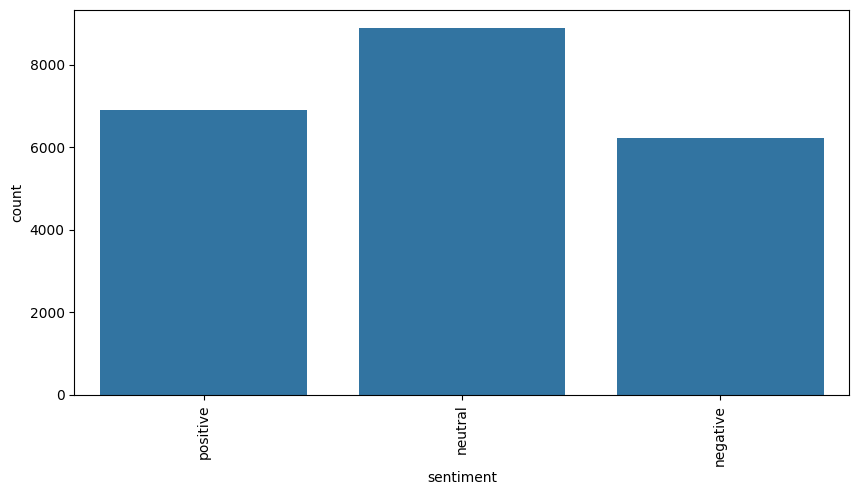

Train Pred Targets


,count
neutral,10606
positive,6470
negative,4908


,proportion
neutral,48.0
positive,30.0
negative,22.0


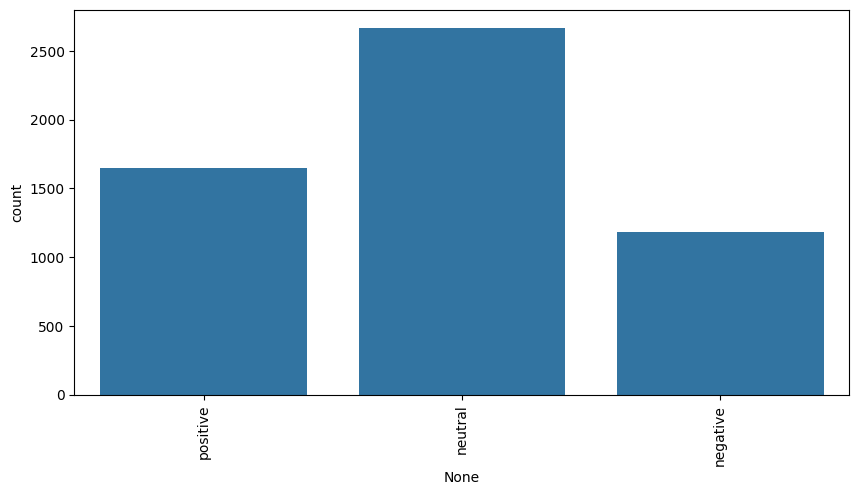

In [173]:
print('Train Targets')
display(pd.Series(y_train).value_counts())
display(pd.Series(y_train).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(y_train))
plt.xticks(rotation = 90)
plt.show()

print('Train Pred Targets')
display(pd.Series(train_preds_lgb_tfidf).value_counts())
display(pd.Series(test_preds_lgb_tfidf).value_counts(normalize=True).round(2)*100)

plt.figure(figsize = (10,5))
sns.countplot(x = pd.Series(test_preds_lgb_tfidf))
plt.xticks(rotation = 90)
plt.show()

In [174]:
print("Train:")
display(f'Train F1: {f1_score(y_train, train_preds_lgb_tfidf, average="weighted"):.2f}')
print(classification_report(y_train, train_preds_lgb_tfidf))

print("Test:")
display(f'Test F1: {f1_score(y_test, test_preds_lgb_tfidf, average="weighted"):.2f}')
print(classification_report(y_test, test_preds_lgb_tfidf))

Train:


'Train F1: 0.76'

              precision    recall  f1-score   support

    negative       0.82      0.65      0.72      6209
     neutral       0.69      0.83      0.75      8881
    positive       0.82      0.77      0.80      6894

    accuracy                           0.76     21984
   macro avg       0.78      0.75      0.76     21984
weighted avg       0.77      0.76      0.76     21984

Test:


'Test F1: 0.70'

              precision    recall  f1-score   support

    negative       0.74      0.56      0.64      1572
     neutral       0.64      0.77      0.70      2236
    positive       0.77      0.75      0.76      1688

    accuracy                           0.70      5496
   macro avg       0.72      0.69      0.70      5496
weighted avg       0.71      0.70      0.70      5496



Бачимо, що якість класифікатора загалом не змінилася

Аналіз впливу ознак на класифікацію

In [175]:
feature_importance = pd.Series(model_lgb_tfidf.feature_importances_, index=vectorizer_tfidf.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance.head(20)

,imp
love,114
miss,105
thank,99
hope,91
good,88
great,83
awesom,78
happi,77
sad,77
hate,76


In [176]:
model_lgb_tfidf.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [177]:
# Get the list of SHAP arrays (one array per class)
shap_contrib = model_lgb_tfidf.predict(X_test_float_tfidf, pred_contrib=True)

# Get the model's actual predictions for the test set
test_preds = model_lgb_tfidf.predict(X_test_float_tfidf)

# Define classes based on model_lgb_tfidf.classes_ order
class_labels = ['negative', 'neutral', 'positive']

for class_idx, class_name in enumerate(class_labels):
    # Get SHAP values for this specific class
    class_shap = shap_contrib[class_idx][:, :-1]
    if hasattr(class_shap, "toarray"):
        class_shap = class_shap.toarray()

    # Select only rows where the model predicted this class
    predicted_as_class = (test_preds == class_name)

    if np.sum(predicted_as_class) > 0:
        # Calculate mean absolute SHAP only on rows belonging to this prediction
        mean_shap = np.abs(class_shap[predicted_as_class]).mean(axis=0)

        feat_imp = pd.Series(
            mean_shap,
            index=vectorizer_tfidf.get_feature_names_out(),
            name=f'shap_{class_name}'
        ).sort_values(ascending=False)

        print(f"\n--- Top 10 Features defining '{class_name.upper()}' predictions ---")
        print(feat_imp.head(10))

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Top 10 Features defining 'NEGATIVE' predictions ---
miss     0.217517
sad      0.180475
sorri    0.102589
hate     0.099346
love     0.091430
suck     0.074426
bad      0.071811
feel     0.067742
bore     0.065972
hurt     0.061270
Name: shap_negative, dtype: float32

--- Top 10 Features defining 'NEUTRAL' predictions ---
happi     0.035551
thank     0.032233
good      0.030921
love      0.028812
like      0.016937
feel      0.016023
back      0.015832
realli    0.015445
miss      0.014879
great     0.013603
Name: shap_neutral, dtype: float32

--- Top 10 Features defining 'POSITIVE' predictions ---
love      0.268322
good      0.228037
thank     0.221411
happi     0.193659
great     0.108188
hope      0.095930
nice      0.095284
fun       0.072901
enjoy     0.064835
awesom    0.058331
Name: shap_positive, dtype: float32


Бачимо, що результати подібні для однакових роподілів даних та векторизації на моделях BoW та TF-IDF

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

Аналіз помилок буде здійснено за допомогою таблиці помилок

In [182]:
test_tfidf_proba = model_lgb_tfidf.predict_proba(X_test_tfidf.astype('float32')).round(2)

In [181]:
errors_df = pd.DataFrame({
    'text': X_test,
    'y_true': y_test,
    'y_pred_tfidf': test_preds_lgb_tfidf,
})

In [183]:
errors_df['proba_tfidf'] = test_tfidf_proba.tolist()
wrong = errors_df[errors_df.y_true != errors_df.y_pred_tfidf]

Найчастіші помилки в класах

In [184]:
wrong.groupby(['y_true','y_pred_tfidf']).size().sort_values(ascending=False).head(10)

y_true    y_pred_tfidf
negative  neutral         582
positive  neutral         365
neutral   positive        269
          negative        249
negative  positive        112
positive  negative         55
dtype: int64

Бачимо, що найчастіше модель помиляється у негативних класах, вказуючи текст як нейтральний клас

Помилки з високою впевненістю

In [190]:
wrong.assign(conf=wrong.proba_tfidf.map(max)).sort_values('conf', ascending=False).head(20)

,text,y_true,y_pred_tfidf,proba_tfidf,conf
26901,Happy Mother`s Day to every mommy out there,negative,positive,"[0.01, 0.03, 0.95]",0.95
23480,The hair looks sicckkkk. Happy mothers day to...,neutral,positive,"[0.02, 0.04, 0.95]",0.95
14462,Thanks for the follow my new Twitpeeps!,negative,positive,"[0.01, 0.05, 0.94]",0.94
24329,"fuckkk i need sleepppppppp lol, happy mothers ...",neutral,positive,"[0.01, 0.05, 0.94]",0.94
5129,6th street was amazing this weekend!!! The wed...,neutral,positive,"[0.05, 0.02, 0.93]",0.93
14772,yummy thanks strangely quiet too. Kids are d...,neutral,positive,"[0.01, 0.06, 0.93]",0.93
14407,Aww what a sunny day! Tasty barbeque with the ...,neutral,negative,"[0.93, 0.05, 0.02]",0.93
15281,- i can do 'Nana' or 'Nana Rocks' for you in ...,neutral,positive,"[0.01, 0.07, 0.92]",0.92
23368,feeling sorry for Ian. He broke up with his gf...,neutral,negative,"[0.92, 0.07, 0.01]",0.92
16279,_in_love aww me too!!! we miss you.,positive,negative,"[0.92, 0.06, 0.02]",0.92


Бачимо, що часто деякі слова, які мають високі feature importance (наприклад, happy) майже визначають клас. У деяких реченнях бачимо, що слово 'happy' вирване з контексту, в той час як самі речення мають негативний маркер.
Також видно речення, у яких наявний сарказм та неоднозначні вирази, які потрібно трактувати в контексті.

Для покращення класифікації можна спробувати використовувати n-грами (ngram_range=(1, 3) чи (1, 2)). Таким чином можливо уникнути частини виривання слова з контексту.
Також у TF-IDF можна додатково обмежити високочастотні слова (max_df) (те ж слово happy, наприклад, оскільки часто воно використовується у саркастичному значенні)

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model